<a href="https://colab.research.google.com/github/VitorMiller/VitorMiller-Redes-Neurais-ArtificiaisMPCA/blob/main/Implementa%C3%A7%C3%A3o_do_Backpropagation_em_Python_Tarefa_Vitor_Miller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importações

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(42)

Funções de Definição

In [ ]:
def plotDataset(X, y, title=None):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6, cmap=plt.cm.Spectral)
    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

In [ ]:
def makeLogicalDataset(n=80, func=lambda a, b: bool(a) != bool(b), random_state=42):
    X, y = make_blobs(
        n_samples=n,
        centers=[[0, 0], [1, 0], [1, 1], [0, 1]],
        cluster_std=0.1,
        random_state=random_state
    )

    y = np.array(
        [func(a > 0.5, b > 0.5) for a, b in zip(X[:, 0], X[:, 1])],
        dtype=int
    ) * 2 - 1

    return X, y

In [ ]:
def makeHardDataset(n=250, centers=10, std=0.5, random_state=8):
    X, y = make_blobs(
        n_samples=n,
        centers=centers,
        cluster_std=std,
        random_state=random_state
    )

    y = np.where(y % 2 == 0, -1, 1)
    return X, y

In [ ]:
def defineAxes(X):
    offset = 0.5
    min1, max1 = X[:, 0].min() - offset, X[:, 0].max() + offset
    min2, max2 = X[:, 1].min() - offset, X[:, 1].max() + offset
    return [min1, max1, min2, max2]

In [ ]:
def plotPredictions(model, X, scaler=None, title=None):
    axes = defineAxes(X)
    x0s = np.linspace(axes[0], axes[1], 200)
    x1s = np.linspace(axes[2], axes[3], 200)
    x0, x1 = np.meshgrid(x0s, x1s)

    X_grid = np.c_[x0.ravel(), x1.ravel()]

    if scaler is not None:
        X_grid_model = scaler.transform(X_grid)
    else:
        X_grid_model = X_grid

    ypred = model.predict(X_grid_model).reshape(x0.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)
    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

In [ ]:
def include_bias(X):
    # Inclui a coluna de bias no início da matriz.
    return np.hstack((np.ones((X.shape[0], 1)), X))


class MLPBackpropagation(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden_layers=(10,),
        activations=None,
        max_iter=5000,
        learning_rate=0.01,
        random_state=42,
        verbose=False
    ):
        self.hidden_layers = hidden_layers
        self.activations = activations
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.verbose = verbose

    def _activation(self, z, name):
        # Calcula a ativação de uma camada.
        if name == "tanh":
            return np.tanh(z)
        elif name == "sigmoid":
            return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        elif name == "relu":
            return np.maximum(0, z)
        elif name == "linear":
            return z
        else:
            raise ValueError(f"Função de ativação não suportada: {name}")

    def _activation_derivative(self, z, name):
        # Calcula a derivada da função de ativação.
        if name == "tanh":
            a = np.tanh(z)
            return 1 - a**2
        elif name == "sigmoid":
            s = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
            return s * (1 - s)
        elif name == "relu":
            return (z > 0).astype(float)
        elif name == "linear":
            return np.ones_like(z)
        else:
            raise ValueError(f"Função de ativação não suportada: {name}")

    def _validate_activations(self):
        # Deve existir uma ativação para cada camada oculta e uma para a saída.
        n_layers = len(self.hidden_layers) + 1

        if self.activations is None:
            self.activations_ = ["tanh"] * n_layers
        else:
            if len(self.activations) != n_layers:
                raise ValueError(
                    f"activations deve ter {n_layers} elementos: "
                    f"uma função para cada camada oculta e uma para a camada de saída."
                )
            self.activations_ = list(self.activations)

    def _initialize_weights(self, n_features, n_outputs):
        # Inicializa os pesos da rede.
        # Cada matriz de pesos possui uma linha extra por causa do bias.
        rng = np.random.default_rng(self.random_state)

        layer_sizes = [n_features] + list(self.hidden_layers) + [n_outputs]
        self.Ws = []

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            limit = np.sqrt(6 / (fan_in + fan_out))
            W = rng.uniform(-limit, limit, size=(fan_in + 1, fan_out))
            self.Ws.append(W)

    def forward(self, X):
        # Propagação para frente.
        # Guarda A e Z para serem usados no backpropagation.
        self.A = []
        self.Z = []

        output = X.copy()

        for W, activation_name in zip(self.Ws, self.activations_):
            A_bias = include_bias(output)
            Z = A_bias @ W
            output = self._activation(Z, activation_name)

            self.A.append(A_bias)
            self.Z.append(Z)

        return output

    def backward(self, y, y_pred):
        # Backpropagation usando erro quadrático médio.
        n = y.shape[0]
        deltas = [None] * len(self.Ws)

        # Delta da camada de saída.
        deltas[-1] = (2 * (y_pred - y) / n) * self._activation_derivative(
            self.Z[-1],
            self.activations_[-1]
        )

        # Deltas das camadas ocultas.
        for i in range(len(self.Ws) - 2, -1, -1):
            W_next_without_bias = self.Ws[i + 1][1:, :]
            deltas[i] = (deltas[i + 1] @ W_next_without_bias.T) * self._activation_derivative(
                self.Z[i],
                self.activations_[i]
            )

        # Atualização dos pesos.
        for i in range(len(self.Ws)):
            grad = self.A[i].T @ deltas[i]
            self.Ws[i] -= self.learning_rate * grad

    def fit(self, X, y):
        # Treina o MLP.
        # Para classificação binária, o alvo usado internamente é -1 e 1.
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)

        # Caso y esteja em 0/1, converte para -1/1 internamente.
        if set(self.classes_) == {0, 1}:
            y_train = np.where(y == 0, -1, 1)
        else:
            y_train = y.copy()

        if y_train.ndim == 1:
            y_train = y_train.reshape(-1, 1)

        self._validate_activations()
        self._initialize_weights(n_features=X.shape[1], n_outputs=y_train.shape[1])

        self.loss_history_ = []

        for epoch in range(self.max_iter):
            y_pred = self.forward(X)
            loss = np.mean((y_train - y_pred) ** 2)
            self.loss_history_.append(loss)

            self.backward(y_train, y_pred)

            if self.verbose and epoch % 1000 == 0:
                print(f"Época {epoch:5d} | MSE: {loss:.6f}")

        return self

    def predict(self, X):
        # Realiza a predição.
        # A saída contínua da rede é convertida para classe usando o sinal.
        X = np.asarray(X, dtype=float)
        y_pred = self.forward(X)

        labels = np.where(y_pred >= 0, 1, -1).ravel()

        # Se o modelo recebeu classes 0/1 no treinamento, retorna 0/1.
        if set(self.classes_) == {0, 1}:
            labels = np.where(labels == -1, 0, 1)

        return labels

Teste 1: XOR

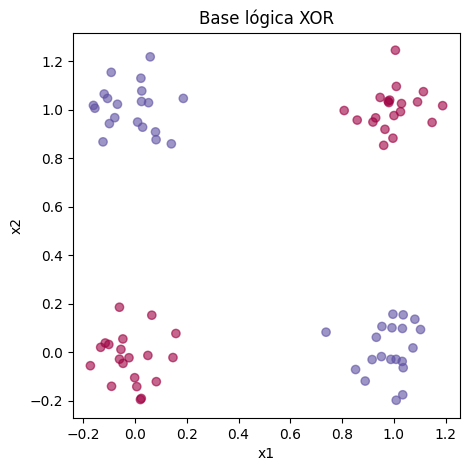

In [ ]:
X, y = makeLogicalDataset(n=80, random_state=42)
plotDataset(X, y, title="Base lógica XOR")

In [ ]:
scaler_xor = StandardScaler()
X_scaled = scaler_xor.fit_transform(X)

mlp_xor = MLPBackpropagation(
    hidden_layers=(4,),
    activations=("tanh", "tanh"),
    max_iter=5000,
    learning_rate=0.05,
    random_state=42
)

mlp_xor.fit(X_scaled, y)

y_pred_xor = mlp_xor.predict(X_scaled)
acc_xor = accuracy_score(y, y_pred_xor)

print(f"Acurácia do MLP manual no XOR: {acc_xor:.4f}")

Acurácia do MLP manual no XOR: 1.0000


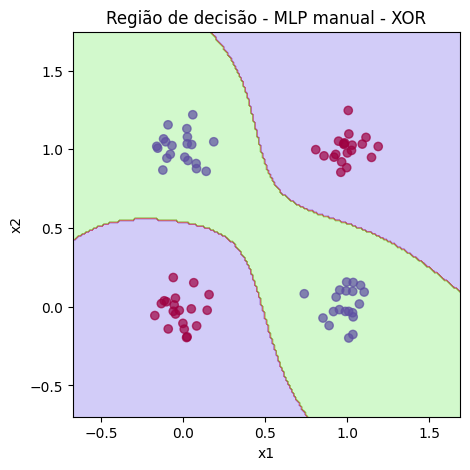

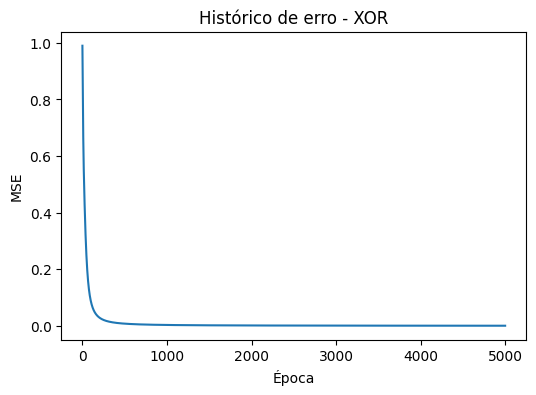

In [ ]:
plotPredictions(mlp_xor, X, scaler=scaler_xor, title="Região de decisão - MLP manual - XOR")
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.7, cmap=plt.cm.Spectral)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(mlp_xor.loss_history_)
plt.title("Histórico de erro - XOR")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.show()

Teste 2: base mais difícil

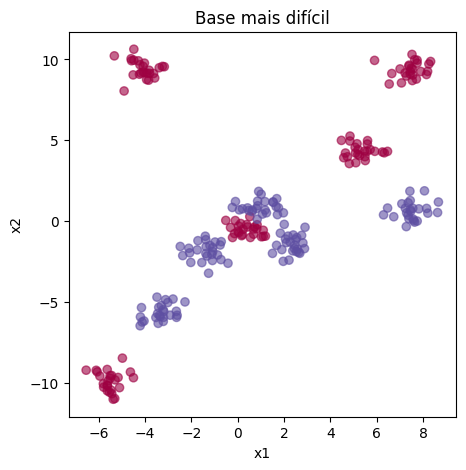

In [ ]:
X, y = makeHardDataset(n=250, centers=10, std=0.5, random_state=8)

plotDataset(X, y, title="Base mais difícil")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler_hard = StandardScaler()
X_train_scaled = scaler_hard.fit_transform(X_train)
X_test_scaled = scaler_hard.transform(X_test)

In [ ]:
mlp_manual = MLPBackpropagation(
    hidden_layers=(20, 10),
    activations=("tanh", "tanh", "tanh"),
    max_iter=7000,
    learning_rate=0.03,
    random_state=42
)

mlp_manual.fit(X_train_scaled, y_train)

y_pred_manual = mlp_manual.predict(X_test_scaled)
acc_manual = accuracy_score(y_test, y_pred_manual)

print(f"Acurácia do MLP manual: {acc_manual:.4f}")

Acurácia do MLP manual: 0.9841


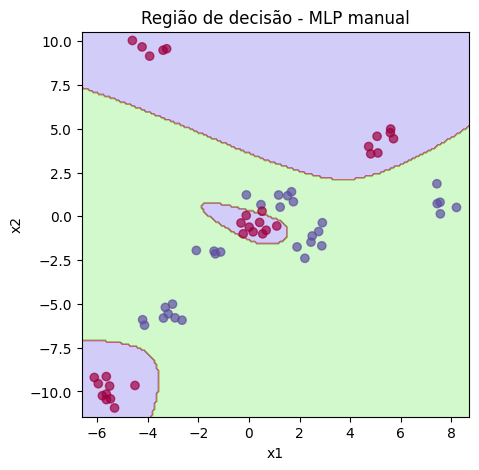

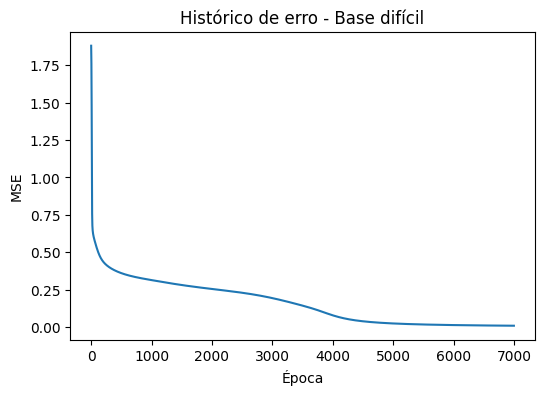

In [ ]:
plotPredictions(mlp_manual, X_test, scaler=scaler_hard, title="Região de decisão - MLP manual")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, alpha=0.7, cmap=plt.cm.Spectral)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(mlp_manual.loss_history_)
plt.title("Histórico de erro - Base difícil")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.show()

Comparação com o Scikit-Learn

A arquitetura escolhida será semelhante à do MLP manual:

- Duas camadas ocultas.
- Primeira camada oculta com 20 neurônios.
- Segunda camada oculta com 10 neurônios.
- Ativação tanh.

In [ ]:
y_train_sklearn = np.where(y_train == -1, 0, 1)
y_test_sklearn = np.where(y_test == -1, 0, 1)

mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(20, 10),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=3000,
    random_state=42
)

mlp_sklearn.fit(X_train_scaled, y_train_sklearn)

y_pred_sklearn_01 = mlp_sklearn.predict(X_test_scaled)
y_pred_sklearn = np.where(y_pred_sklearn_01 == 0, -1, 1)

acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Acurácia do MLP do Scikit-Learn: {acc_sklearn:.4f}")
print(f"Quantidade de iterações do Scikit-Learn: {mlp_sklearn.n_iter_}")

Acurácia do MLP do Scikit-Learn: 0.9841
Quantidade de iterações do Scikit-Learn: 526


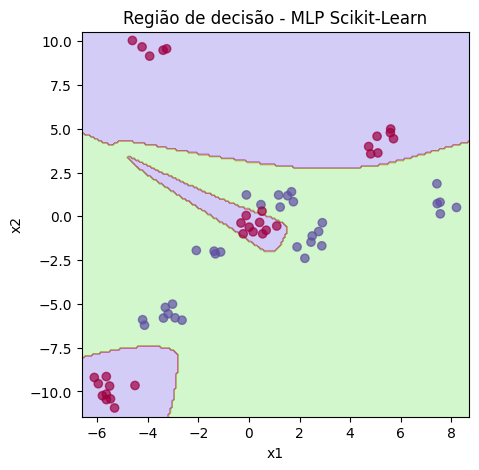

In [ ]:
plotPredictions(mlp_sklearn, X_test, scaler=scaler_hard, title="Região de decisão - MLP Scikit-Learn")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test_sklearn, alpha=0.7, cmap=plt.cm.Spectral)
plt.show()

Tabela comparativa

In [ ]:
resultados = pd.DataFrame({
    "Modelo": ["MLP manual com Backpropagation", "MLPClassifier - Scikit-Learn"],
    "Arquitetura": ["(20, 10)", "(20, 10)"],
    "Ativação": ["tanh, tanh, tanh", "tanh"],
    "Acurácia no teste": [acc_manual, acc_sklearn]
})

resultados

,Modelo,Arquitetura,Ativação,Acurácia no teste
0,MLP manual com Backpropagation,"(20, 10)","tanh, tanh, tanh",0.984127
1,MLPClassifier - Scikit-Learn,"(20, 10)",tanh,0.984127
